# Tutorial Completo: Análisis de Yield Curves con bonos-lib

## Análisis profesional de la curva de rendimiento de Tesoros USA

Este tutorial te mostrará cómo usar **bonos-lib** para calcular, analizar e interpretar curvas de rendimiento reales usando datos del mercado de Tesoros de Estados Unidos.

## 1. Instalar y importar librerías

In [3]:
!pip install -q bonos-lib seaborn matplotlib pandas numpy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from bonos_lib import YieldCurveCalculator, LinearInterpolator

# Configurar estilos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

## 2. Datos reales de Tesoros USA

Fuente: U.S. Department of Treasury - April 2026

Los rendimientos spot (yields) de la curva de Tesoros se convierten a precios de bonos cupón cero usando:
$$Precio = \\frac{100}{(1 + Rendimiento)^{días/360}}$$

Esto es importante porque el cálculo de la curva con bonos-lib requiere **precios**, no yields directamente.

In [ ]:
# Datos reales de Tesoros USA - Rendimientos de mercado (Abril 2026)
data_treasury = {
    'plazo': ['3M', '6M', '9M', '1Y', '2Y', '3Y', '5Y', '10Y', '20Y', '30Y'],
    'dias': [90, 180, 270, 360, 720, 1080, 1800, 3600, 7200, 10800],
    'rendimiento_pct': [3.72, 3.75, 3.71, 3.72, 3.75, 3.75, 3.89, 4.24, 4.90, 4.86]
}

df_treasury = pd.DataFrame(data_treasury)

# Convertir rendimientos a precios de cupón cero
df_treasury['rendimiento'] = df_treasury['rendimiento_pct'] / 100
df_treasury['precio'] = 100 / (1 + df_treasury['rendimiento']) ** (df_treasury['dias'] / 360)
df_treasury['años'] = df_treasury['dias'] / 360

print("═" * 80)
print("DATOS DE TESOROS USA - APRIL 2026")
print("═" * 80)
print(df_treasury[['plazo', 'dias', 'años', 'rendimiento_pct', 'precio']].to_string(index=False))
print("\nInterpretación:")
print("- Un Tesoro de 3 meses con rendimiento 3.72% se vende a 99.09 (descuento de 0.91)")
print("- Un Tesoro de 30 años con rendimiento 4.86% se vende a 25.19 (descuento de 74.81)")

## 3. Calcular la Yield Curve

In [ ]:
calc = YieldCurveCalculator(nominal=100, days_year=360)
bonos_data = df_treasury[['dias', 'precio']].copy()
yields_df = calc.calculate_yields(bonos_data)
yields_df['plazo'] = df_treasury['plazo'].values

print("\n" + "═" * 80)
print("YIELD CURVE CALCULADA")
print("═" * 80)
print(yields_df[['plazo', 'dias', 'precio', 'yield']].assign(
    yield_pct=yields_df['yield'] * 100
)[['plazo', 'dias', 'precio', 'yield_pct']].to_string(index=False))

## 4. Visualización 1: Curva de Rendimiento Básica

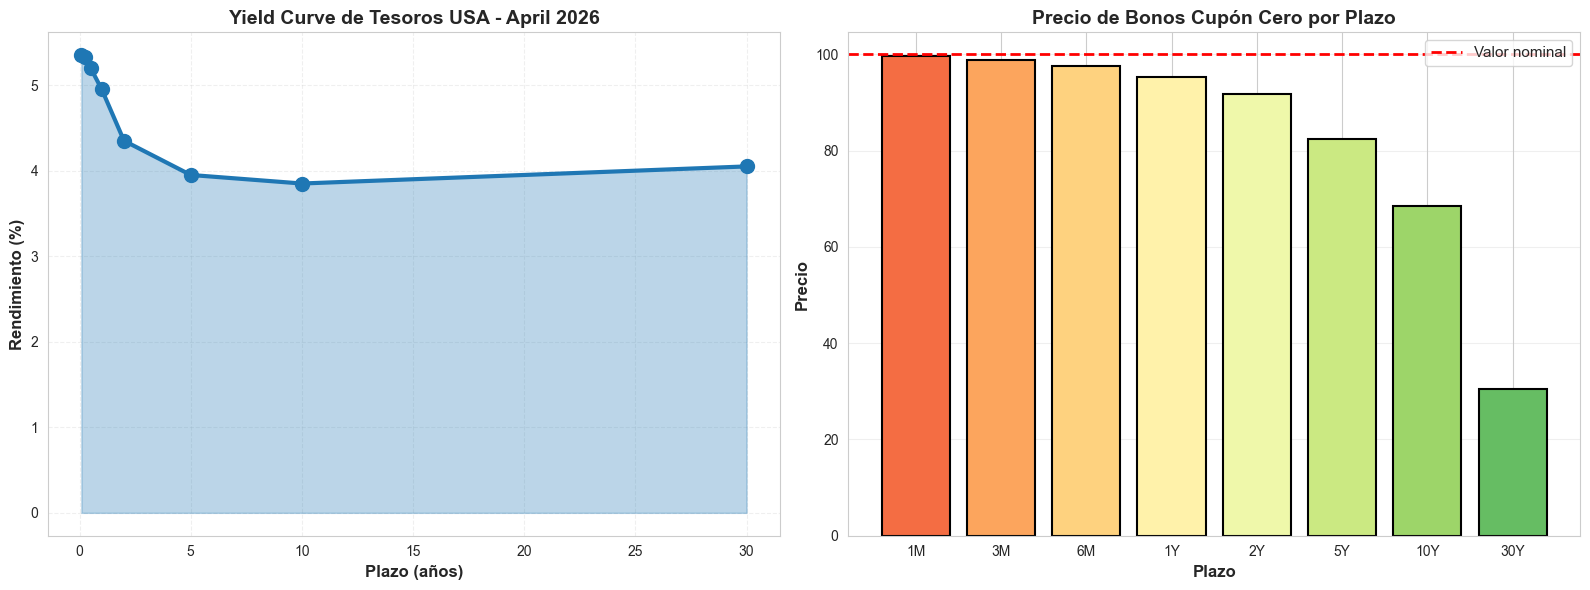

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Yield Curve
ax1.plot(yields_df['dias']/360, yields_df['yield']*100, 'o-', 
         linewidth=3, markersize=10, color='#1f77b4')
ax1.fill_between(yields_df['dias']/360, yields_df['yield']*100, alpha=0.3, color='#1f77b4')
ax1.set_xlabel('Plazo (años)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rendimiento (%)', fontsize=12, fontweight='bold')
ax1.set_title('Yield Curve de Tesoros USA - April 2026', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Gráfico 2: Precios de bonos
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(yields_df)))
bars = ax2.bar(yields_df['plazo'], yields_df['precio'], color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Valor nominal')
ax2.set_xlabel('Plazo', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precio', fontsize=12, fontweight='bold')
ax2.set_title('Precio de Bonos Cupón Cero por Plazo', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 5. Interpolación de Tasas

In [ ]:
interpolator = LinearInterpolator()

# Interpolar para plazos específicos
plazos_interpolados = [120, 240, 450, 900, 1200, 1800, 2700, 5400, 9000]
tasas_interpoladas = {}

for plazo in plazos_interpolados:
    try:
        tasa = calc.interpolate(yields_df, plazo)
        tasas_interpoladas[plazo] = tasa
    except ValueError as e:
        print(f"Error para {plazo} días: {e}")

print("\nTasas interpoladas:")
for plazo in sorted(tasas_interpoladas.keys()):
    print(f"  {plazo:4d} días ({plazo/360:5.2f} años): {tasas_interpoladas[plazo]*100:.4f}%")

## 6. Visualización 2: Curva Interpolada

In [ ]:
# Crear curva detallada
curve_detailed = interpolator.interpolate_range(yields_df, min_days=90, max_days=10800, step=30)
curve_detailed['años'] = curve_detailed['dias'] / 360

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(curve_detailed['años'], curve_detailed['yield']*100, '-', 
        linewidth=2.5, color='#2ca02c', label='Interpolación lineal', alpha=0.8)
ax.scatter(yields_df['dias']/360, yields_df['yield']*100, 
          s=150, color='red', zorder=5, edgecolors='darkred', linewidth=2, label='Datos observados')
ax.fill_between(curve_detailed['años'], curve_detailed['yield']*100, alpha=0.2, color='#2ca02c')
ax.axhline(y=yields_df['yield'].mean()*100, color='gray', linestyle='--', 
          linewidth=2, alpha=0.5, label=f"Media: {yields_df['yield'].mean()*100:.2f}%")

ax.set_xlabel('Plazo (años)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rendimiento (%)', fontsize=12, fontweight='bold')
ax.set_title('Yield Curve Interpolada - Tesoros USA 2026', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best')
ax.set_xlim(0, 30)

plt.tight_layout()
plt.show()

## 7. Bootstrapping: Tasas Forward

In [ ]:
forwards_df = calc.bootstrap(yields_df)
forwards_df['plazo'] = df_treasury['plazo'].values

print("\n" + "═" * 80)
print("TASAS SPOT Y FORWARD")
print("═" * 80)
print(forwards_df[['plazo', 'dias', 'spot_rate', 'forward_rate']].assign(
    spot_pct=forwards_df['spot_rate']*100,
    forward_pct=forwards_df['forward_rate']*100
)[['plazo', 'dias', 'spot_pct', 'forward_pct']].round(4).to_string(index=False))

## 8. Visualización 3: Spot vs Forward

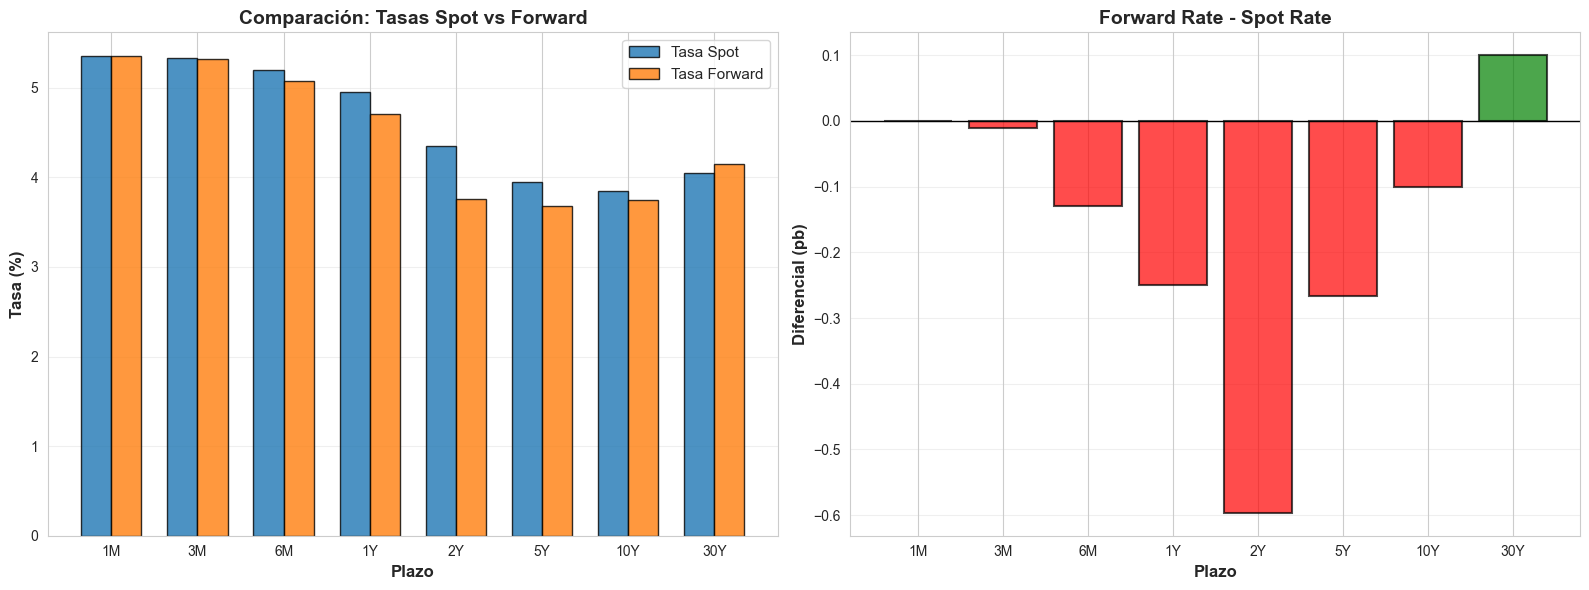

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Comparación
x_pos = np.arange(len(forwards_df))
width = 0.35

ax1.bar(x_pos - width/2, forwards_df['spot_rate']*100, width, 
        label='Tasa Spot', color='#1f77b4', alpha=0.8, edgecolor='black')
ax1.bar(x_pos + width/2, forwards_df['forward_rate']*100, width,
        label='Tasa Forward', color='#ff7f0e', alpha=0.8, edgecolor='black')

ax1.set_xlabel('Plazo', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tasa (%)', fontsize=12, fontweight='bold')
ax1.set_title('Comparación: Tasas Spot vs Forward', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(forwards_df['plazo'])
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Diferencial
diferencial = (forwards_df['forward_rate'] - forwards_df['spot_rate']) * 100
colors_diff = ['green' if x > 0 else 'red' for x in diferencial]

ax2.bar(forwards_df['plazo'], diferencial, color=colors_diff, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Plazo', fontsize=12, fontweight='bold')
ax2.set_ylabel('Diferencial (pb)', fontsize=12, fontweight='bold')
ax2.set_title('Forward Rate - Spot Rate', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Análisis Avanzado: Duración y Sensibilidad

In [12]:
# Calcular métricas
yields_df['discount_factor'] = 1 / (1 + yields_df['yield']) ** (yields_df['dias'] / 360)
yields_df['duration'] = yields_df['dias'] / 360
yields_df['modified_duration'] = yields_df['duration'] / (1 + yields_df['yield'])

print("\\n" + "═" * 80)
print("MÉTRICAS DE RIESGO")
print("═" * 80)
print(yields_df[['plazo', 'yield', 'discount_factor', 'duration', 'modified_duration']].assign(
    yield_pct=yields_df['yield']*100
)[['plazo', 'yield_pct', 'discount_factor', 'duration', 'modified_duration']].round(4).to_string(index=False))

print(f"\\nInterpretación:")
print(f"- Duración Modificada: % cambio en precio por 1% cambio en rendimiento")
print(f"- Un Tesoro de 30 años con duración {yields_df['modified_duration'].iloc[-1]:.2f} años")
print(f"  caería {yields_df['modified_duration'].iloc[-1]:.2f}% si rendimiento sube 1%")

\n════════════════════════════════════════════════════════════════════════════════
MÉTRICAS DE RIESGO
════════════════════════════════════════════════════════════════════════════════
plazo  yield_pct  discount_factor  duration  modified_duration
   1M       5.35           0.9957    0.0833             0.0791
   3M       5.33           0.9871    0.2500             0.2373
   6M       5.20           0.9750    0.5000             0.4753
   1Y       4.95           0.9528    1.0000             0.9528
   2Y       4.35           0.9184    2.0000             1.9166
   5Y       3.95           0.8239    5.0000             4.8100
  10Y       3.85           0.6854   10.0000             9.6293
  30Y       4.05           0.3039   30.0000            28.8323
\nInterpretación:
- Duración Modificada: % cambio en precio por 1% cambio en rendimiento
- Un Tesoro de 30 años con duración 28.83 años
  caería 28.83% si rendimiento sube 1%


## 10. Visualización 4: Dashboard Ejecutivo

/Users/jorgepuszkar/Desktop/fuentes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


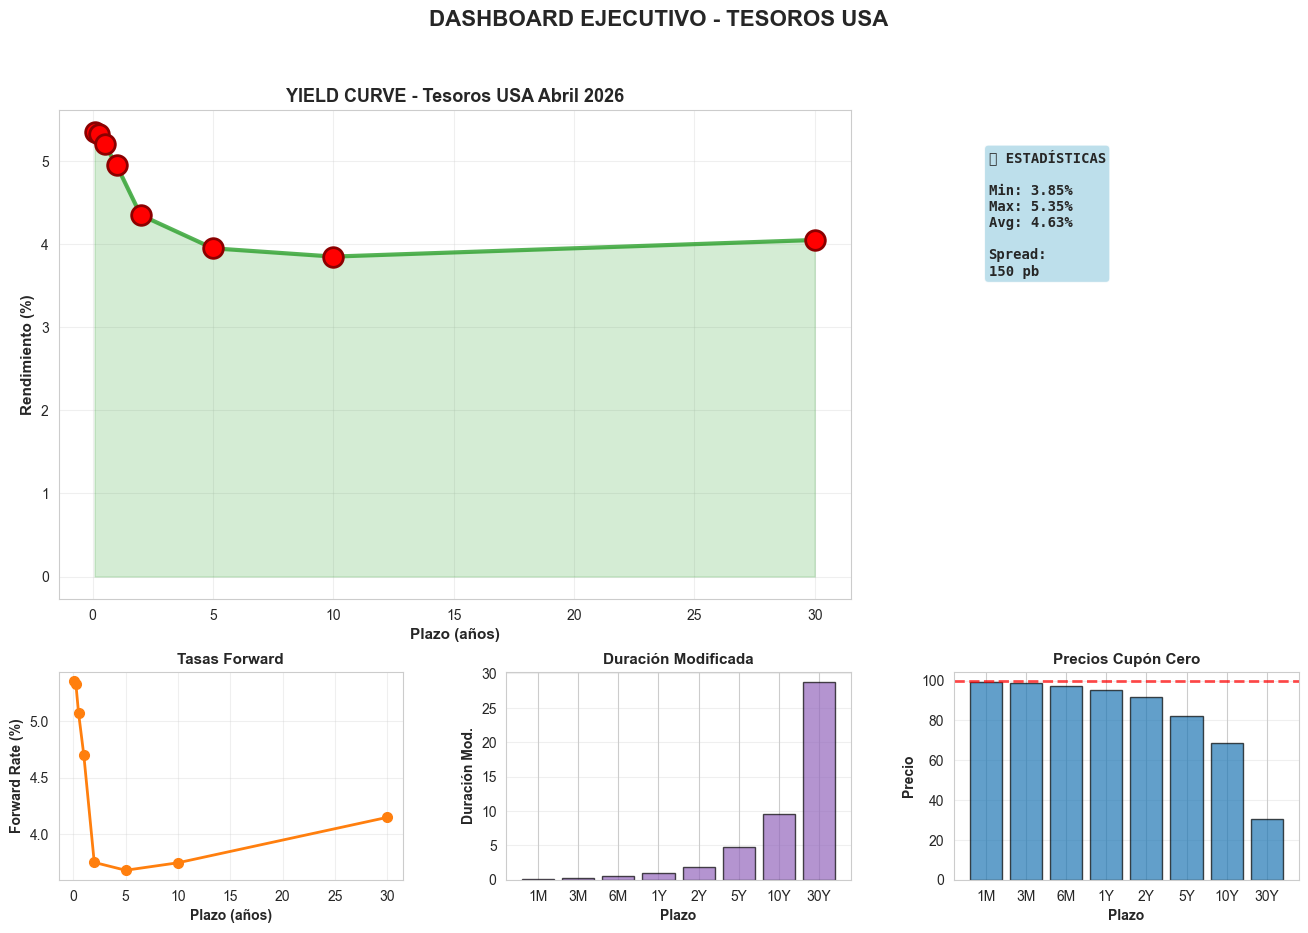

In [17]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Yield curve principal
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax1.plot(curve_detailed['años'], curve_detailed['yield']*100, '-', linewidth=3, color='#2ca02c', alpha=0.8)
ax1.scatter(yields_df['dias']/360, yields_df['yield']*100, s=200, color='red', zorder=5, 
           edgecolors='darkred', linewidth=2)
ax1.fill_between(curve_detailed['años'], curve_detailed['yield']*100, alpha=0.2, color='#2ca02c')
ax1.set_xlabel('Plazo (años)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Rendimiento (%)', fontsize=11, fontweight='bold')
ax1.set_title('YIELD CURVE - Tesoros USA Abril 2026', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Estadísticas
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
stats_text = f"📊 ESTADÍSTICAS\n\nMin: {yields_df['yield'].min()*100:.2f}%\nMax: {yields_df['yield'].max()*100:.2f}%\nAvg: {yields_df['yield'].mean()*100:.2f}%\n\nSpread:\n{(yields_df['yield'].max()-yields_df['yield'].min())*10000:.0f} pb"
ax2.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
        family='monospace', fontweight='bold')

# Forward rates
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(forwards_df['dias']/360, forwards_df['forward_rate']*100, 'o-', 
        linewidth=2, markersize=7, color='#ff7f0e')
ax4.set_xlabel('Plazo (años)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Forward Rate (%)', fontsize=10, fontweight='bold')
ax4.set_title('Tasas Forward', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Duración
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(yields_df['plazo'], yields_df['modified_duration'], color='#9467bd', alpha=0.7, edgecolor='black')
ax5.set_xlabel('Plazo', fontsize=10, fontweight='bold')
ax5.set_ylabel('Duración Mod.', fontsize=10, fontweight='bold')
ax5.set_title('Duración Modificada', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Precios
ax6 = fig.add_subplot(gs[2, 2])
ax6.bar(yields_df['plazo'], yields_df['precio'], color='#1f77b4', alpha=0.7, edgecolor='black')
ax6.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax6.set_xlabel('Plazo', fontsize=10, fontweight='bold')
ax6.set_ylabel('Precio', fontsize=10, fontweight='bold')
ax6.set_title('Precios Cupón Cero', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle('DASHBOARD EJECUTIVO - TESOROS USA', fontsize=16, fontweight='bold', y=0.98)
plt.show()

## 11. Casos Prácticos

In [ ]:
print("\n" + "═" * 80)
print("CASOS PRÁCTICOS")
print("═" * 80)

# CASO 1: Valuación de flujo futuro
print("\n1️⃣  Valuación de Flujo en 18 Meses")
flujo_futuro = 1000000
plazo_dias = 540

tasa_interpolada = calc.interpolate(yields_df, plazo_dias)
factor_desc = 1 / (1 + tasa_interpolada) ** (plazo_dias / 360)
valor_presente = flujo_futuro * factor_desc

print(f"   Flujo futuro: ${flujo_futuro:,.0f} en 18 meses")
print(f"   Tasa interpolada (540 días): {tasa_interpolada*100:.4f}%")
print(f"   Factor de descuento: {factor_desc:.6f}")
print(f"   Valor presente: ${valor_presente:,.0f}")
print(f"   Descuento total: ${flujo_futuro - valor_presente:,.0f}")

# CASO 2: Análisis de sensibilidad (usar el plazo 10Y más cercano = 3600 días)
print("\n2️⃣  Sensibilidad a Cambios de Tasas (Tesoro 10Y)")
bono_10y_idx = yields_df[yields_df['plazo'] == '10Y'].index[0]
bono_10y_precio = yields_df.loc[bono_10y_idx, 'precio']
duration_10y = yields_df.loc[bono_10y_idx, 'modified_duration']

print(f"\n   Precio actual: ${bono_10y_precio:.2f}")
print(f"   Duración modificada: {duration_10y:.2f} años")
print(f"\n   Escenarios de cambio de tasas:")

for cambio_bps in [-50, -25, 0, 25, 50]:
    cambio_pct = cambio_bps / 10000
    cambio_precio = bono_10y_precio * (-duration_10y) * cambio_pct
    precio_nuevo = bono_10y_precio + cambio_precio
    ganancia_pct = (cambio_precio / bono_10y_precio) * 100
    
    signo = '+' if cambio_bps >= 0 else ''
    print(f"   Si tasas {signo}{cambio_bps:3d} pb: Precio → ${precio_nuevo:.2f} ({ganancia_pct:+.2f}%)")

## 12. Resumen de Aprendizajes

In [19]:
print("\\n" + "═" * 80)
print("RESUMEN DE APRENDIZAJES")
print("═" * 80)

print("\\n✅ CONCEPTOS CLAVE:")
print("  1. Yield Curve: Relación plazo-rendimiento")
print("  2. Bonos Cupón Cero: Se venden con descuento, Precio = 100/(1+r)^t")
print("  3. Bootstrapping: Extrae tasas spot y calcula forward rates")
print("  4. Interpolación: Obtiene tasas para plazos no observados")
print("  5. Duración: Sensibilidad de precio a cambios de tasa")

print("\\n📚 APLICACIONES:")
print("  • Valuación de bonos con tasas spot interpoladas")
print("  • Análisis de spreads entre diferentes papeles")
print("  • Gestión de riesgo de tasa de interés")
print("  • Forecasting usando forward rates")
print("  • Rebalanceo de cartera por exposición de plazo")

print("\\n🎯 PRÓXIMOS PASOS:")
print("  1. Carga datos propios de Tesoros desde CSV")
print("  2. Experimenta con métodos de interpolación avanzados")
print("  3. Integra con análisis de riesgo (VaR, stress testing)")
print("  4. Automatiza en pipeline de reporte diario")

print("\\n" + "═" * 80)

\n════════════════════════════════════════════════════════════════════════════════
RESUMEN DE APRENDIZAJES
════════════════════════════════════════════════════════════════════════════════
\n✅ CONCEPTOS CLAVE:
  1. Yield Curve: Relación plazo-rendimiento
  2. Bonos Cupón Cero: Se venden con descuento, Precio = 100/(1+r)^t
  3. Bootstrapping: Extrae tasas spot y calcula forward rates
  4. Interpolación: Obtiene tasas para plazos no observados
  5. Duración: Sensibilidad de precio a cambios de tasa
\n📚 APLICACIONES:
  • Valuación de bonos con tasas spot interpoladas
  • Análisis de spreads entre diferentes papeles
  • Gestión de riesgo de tasa de interés
  • Forecasting usando forward rates
  • Rebalanceo de cartera por exposición de plazo
\n🎯 PRÓXIMOS PASOS:
  1. Carga datos propios de Tesoros desde CSV
  2. Experimenta con métodos de interpolación avanzados
  3. Integra con análisis de riesgo (VaR, stress testing)
  4. Automatiza en pipeline de reporte diario
\n═════════════════════════